In [56]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import plotly as px
import seaborn as sns

Load data


In [57]:
df=pd.read_csv('data.csv') 
df

,unique_mos_id,first_name,last_name,command_now,shield_no,complaint_id,month_received,year_received,month_closed,year_closed,...,mos_age_incident,complainant_ethnicity,complainant_gender,complainant_age_incident,fado_type,allegation,precinct,contact_reason,outcome_description,board_disposition
0,10004,Jonathan,Ruiz,078 PCT,8409,42835,7,2019,5,2020,...,32,Black,Female,38.0,Abuse of Authority,Failure to provide RTKA card,78.0,Report-domestic dispute,No arrest made or summons issued,Substantiated (Command Lvl Instructions)
1,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,24,Black,Male,26.0,Discourtesy,Action,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges)
2,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,24,Black,Male,26.0,Offensive Language,Race,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges)
3,10007,John,Sears,078 PCT,5952,26146,7,2012,9,2013,...,25,Black,Male,45.0,Abuse of Authority,Question,67.0,PD suspected C/V of violation/crime - street,No arrest made or summons issued,Substantiated (Charges)
4,10009,Noemi,Sierra,078 PCT,24058,40253,8,2018,2,2019,...,39,NaN,NaN,16.0,Force,Physical force,67.0,Report-dispute,Arrest - other violation/crime,Substantiated (Command Discipline A)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33353,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,...,36,Asian,Male,21.0,Discourtesy,Word,66.0,Moving violation,Moving violation summons issued,Unsubstantiated
33354,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,...,36,Asian,Male,21.0,Abuse of Authority,Interference with recording,66.0,Moving violation,Moving violation summons issued,Unsubstantiated
33355,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,...,36,Asian,Male,21.0,Abuse of Authority,Search (of person),66.0,Moving violation,Moving violation summons issued,Substantiated (Formalized Training)
33356,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,...,36,Asian,Male,21.0,Abuse of Authority,Vehicle search,66.0,Moving violation,Moving violation summons issued,Substantiated (Formalized Training)


# General viewpoint: 
Black individuals are disproportionately affected to police misconduct in New York City.

## FOR the Proposition: 
Across all FADO types, the proportion of complaints from Black individuals is consistently and significantly high.

In [58]:
race_with_fado_difference=df.groupby('fado_type')['complainant_ethnicity'].value_counts()
race_with_fado_difference

fado_type           complainant_ethnicity
Abuse of Authority  Black                    10359
                    Hispanic                  3676
                    White                     1677
                    Unknown                    580
                    Other Race                 390
                    Asian                      330
                    Refused                    173
                    American Indian             48
Discourtesy         Black                     2290
                    Hispanic                  1026
                    White                      487
                    Unknown                    158
                    Other Race                 124
                    Asian                       86
                    Refused                     41
                    American Indian              8
Force               Black                     4072
                    Hispanic                  1596
                    White               

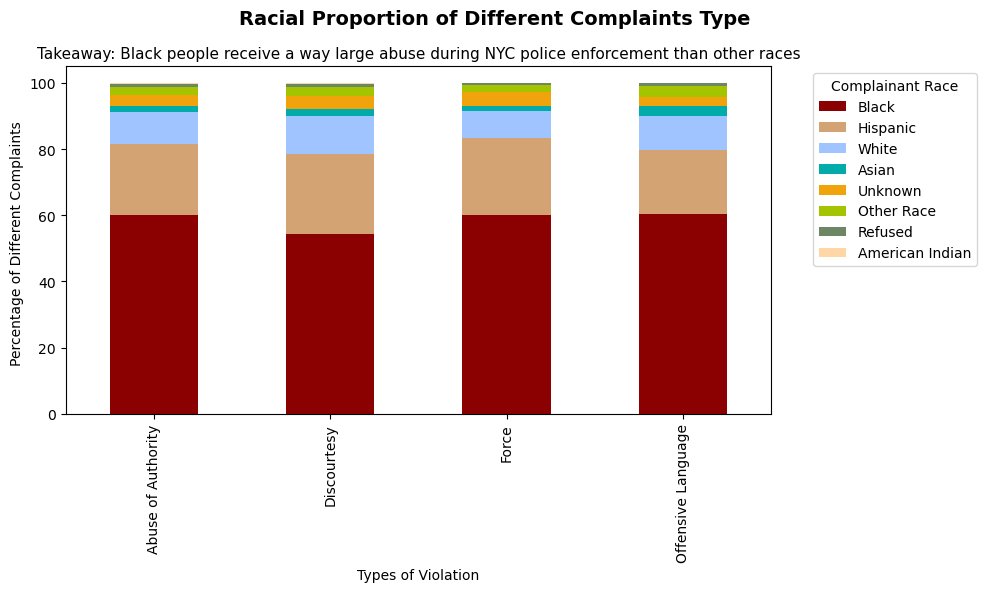

In [59]:
ethnicity_order = [
    'Black', 'Hispanic', 'White', 'Asian', 'Unknown', 
    'Other Race', 'Refused', 'American Indian'
]

custom_colors = [
    '#8B0000',  # dark red for Black
    '#D4A373',  # tan for Hispanic
    '#A0C4FF',  # pastel blue for White
    '#00ABA9',  # soft green for Asian
    '#F0A30A',  # light gray for Unknown
    '#A4C400',  # peach for Other Race
    '#6D8764',  # gray for Refused
    '#FFD6A5'   # pale yellow for American Indian
]

# Reorder your DataFrame columns to match
percent_df = percent_df[ethnicity_order]

# Plot
percent_df.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10, 6), 
    color=custom_colors
)
plt.suptitle("Racial Proportion of Different Complaints Type",fontweight='bold', fontsize=14)
plt.title("Takeaway: Black people receive a way large abuse during NYC police enforcement than other races", fontsize=11)

plt.ylabel("Percentage of Different Complaints ")
plt.xlabel("Types of Violation")
plt.legend(title='Complainant Race', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Design Decisions and Rationale:
* Score: 1.5
* RATIONALE_1: Using stacked bar chart to represent different porportion in one general scale, better than four separate pie chart because you can evaluate and compare their volume by heights.
* RATIONALE_2: Carefully choose a distinct color for Black people to form strong contrast wtih other colors and to show big difference
* RATIONALE_3: Making the color indication box outside the main graph to avoid overlapping

## AGAINST the Proposition: 
The solving time for their cases isn't significantly slower than for other races — suggesting the system doesn’t treat their cases as lower priority.

In [60]:
year_difference=df[['complainant_ethnicity','fado_type','month_received','year_received','month_closed','year_closed']]
year_difference['date_received'] = pd.to_datetime(dict(year=df['year_received'], month=df['month_received'], day=1))
year_difference['date_closed'] = pd.to_datetime(dict(year=df['year_closed'], month=df['month_closed'], day=1))
year_difference['duration']=(year_difference['date_closed']-year_difference['date_received']).dt.days
against_df=year_difference.groupby(['fado_type','complainant_ethnicity'])['duration'].mean().to_frame()

/var/folders/r_/dtq7fgqj6yjcsg3x6bhh56_m0000gn/T/ipykernel_83403/3945659215.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  year_difference['date_received'] = pd.to_datetime(dict(year=df['year_received'], month=df['month_received'], day=1))
/var/folders/r_/dtq7fgqj6yjcsg3x6bhh56_m0000gn/T/ipykernel_83403/3945659215.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  year_difference['date_closed'] = pd.to_datetime(dict(year=df['year_closed'], month=df['month_closed'], day=1))
/var/folders/r_/dtq7fgqj6yjc

In [61]:
against_df=year_difference.groupby(['complainant_ethnicity'])['duration'].mean().to_frame().reset_index()
against_df

,complainant_ethnicity,duration
0,American Indian,271.093750
1,Asian,258.345865
2,Black,320.058607
3,Hispanic,308.947385
4,Other Race,291.090103
5,Refused,265.722008
6,Unknown,310.492795
7,White,284.872080


/var/folders/r_/dtq7fgqj6yjcsg3x6bhh56_m0000gn/T/ipykernel_83403/2513060524.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


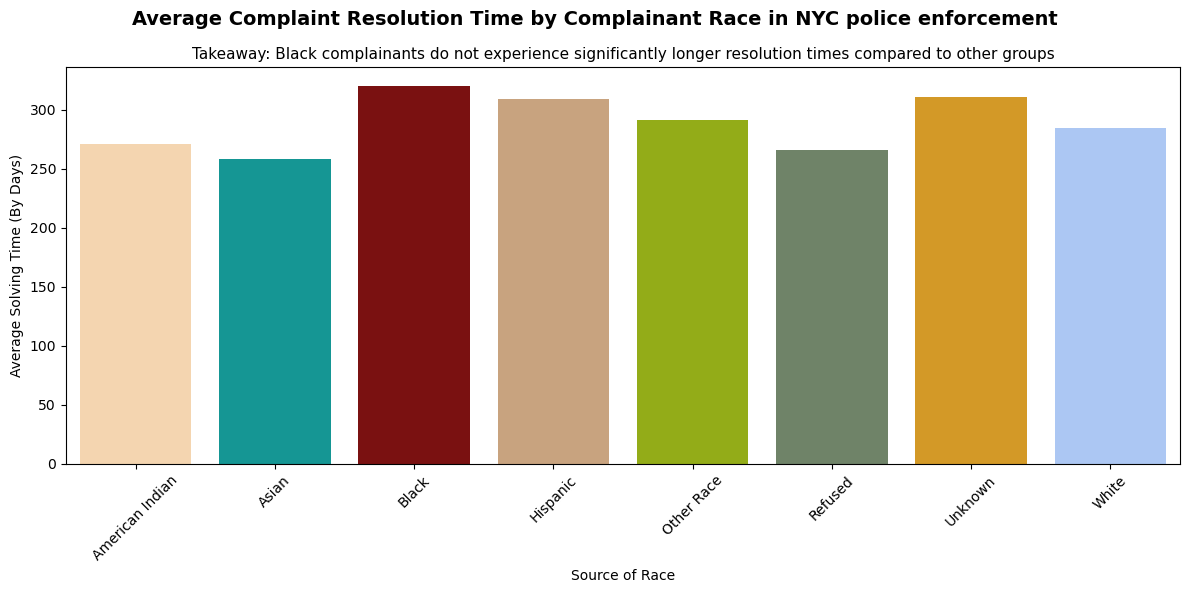

In [62]:
ethnicity_colors = {
    'Black': '#8B0000',
    'Hispanic': '#D4A373',
    'White': '#A0C4FF',
    'Asian': '#00ABA9',
    'Unknown': '#F0A30A',
    'Other Race': '#A4C400',
    'Refused': '#6D8764',
    'American Indian': '#FFD6A5'
}

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(
    data=against_df,
    x='complainant_ethnicity',
    y='duration',
    palette=ethnicity_colors
)
plt.suptitle("Average Complaint Resolution Time by Complainant Race in NYC police enforcement", fontweight='bold', fontsize=14)
plt.title("Takeaway: Black complainants do not experience significantly longer resolution times compared to other groups", fontsize=11)
plt.ylabel("Average Solving Time (By Days)")
plt.xlabel("Source of Race")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Design Decisions and Rationale:
* Score: -1.5
* RATIONALE_1: Using the same color as the supporting graph to easily compare to corresponding races
* RATIONALE_2: Ignore the effects of different Fado type to avoid messiness and complication and choosing the resolution time to making people believe solving time and reports of complaints are the same thing
* RATIONALE_3: Using the average time to extract the effects of big base, and therefore normalize the extreme number effects
8 RATIONALE_4: Adding bold to the title and add a line underneath to add the main takeaway of the picture.

# Final Reflection

After documenting these decisions, write a 2–3 paragraph final reflection on your overall design process across both visualizations. What was straightforward or difficult? What surprised you? How do you now define “ethical analysis and visualization”? What bounds (if any) can you draw to distinguish “acceptable” persuasive choices vs. “misleading” ones (and if none, why not)?

The supporting evidence is really straightforward  because no matter how I adjusted the factors or measurements(including FADO type, proportion and officers'races and etc.) it remains clear that black individuals have the largest share of complainants, so this easy supporting evidence makes it difficult to find a counter-argument. So I have to find other measurements like the solving time to argue against it. 
Now I think the ethical analysis and visualization should be defined as finding fit measurements and representations to show the relationship and correlations especially using representative and earnest data. 
“Acceptable” persuasive choices should be using real data to demonstrate practical complete patterns, while the "misleading"  choice incorporate using unilateral and incomplete data to distort and over generalized conclusion, including maginify marginal differences and using one-sided evidence and measurements. Therefore, it is crucial to include clarity, accuracy and transparency.

# Playing around/Testing

In [63]:
df['fado_type'].value_counts()
byear=df.groupby(['fado_type','year_received','complainant_ethnicity']).count()
byear

unique_mos_id  \
fado_type          year_received complainant_ethnicity                  
Abuse of Authority 1998          Black                              6   
                                 Hispanic                           1   
                   1999          Black                             27   
                                 Hispanic                           8   
                                 Other Race                         1   
...                                                               ...   
Offensive Language 2019          Black                             14   
                                 Hispanic                           9   
                                 Other Race                         1   
                                 Refused                            1   
                                 White                              4   

                                                        first_name  last_name  \
fado_type          year_received complainant_ethnicity                          
Abuse of Authority 1998          Black                           6          6   
                                 Hispanic                        1          1   
                   1999          Black                          27         27   
                                 Hispanic                        8          8   
                                 Other Race                      1          1   
...                                                            ...        ...   
Offensive Language 2019          Black                          14         14   
                                 Hispanic                        9          9   
                                 Other Race                      1          1   
                                 Refused                         1          1   
                                 White                           4          4   

                                                        command_now  \
fado_type          year_received complainant_ethnicity                
Abuse of Authority 1998          Black                            6   
                                 Hispanic                         1   
                   1999          Black                           27   
                                 Hispanic                         8   
                                 Other Race                       1   
...                                                             ...   
Offensive Language 2019          Black                           14   
                                 Hispanic                         9   
                                 Other Race                       1   
                                 Refused                          1   
                                 White                            4   

                                                        shield_no  \
fado_type          year_received complainant_ethnicity              
Abuse of Authority 1998          Black                          6   
                                 Hispanic                       1   
                   1999          Black                         27   
                                 Hispanic                       8   
                                 Other Race                     1   
...                                                           ...   
Offensive Language 2019          Black                         14   
                                 Hispanic                       9   
                                 Other Race                     1   
                                 Refused                        1   
                                 White                          4   

                                                        complaint_id  \
fado_type          year_received complainant_ethnicity                 
Abuse of Authority 1998          Black                             6   
              

demographic difference(race etc.)

In [64]:
officer_victim_demo=df[['mos_ethnicity','mos_gender', 'mos_age_incident', 'complainant_ethnicity', 'complainant_gender', 'complainant_age_incident', 'fado_type']]
officer_victim_demo=officer_victim_demo.dropna()
officer_victim_demo

,mos_ethnicity,mos_gender,mos_age_incident,complainant_ethnicity,complainant_gender,complainant_age_incident,fado_type
0,Hispanic,M,32,Black,Female,38.0,Abuse of Authority
1,White,M,24,Black,Male,26.0,Discourtesy
2,White,M,24,Black,Male,26.0,Offensive Language
3,White,M,25,Black,Male,45.0,Abuse of Authority
5,Black,F,50,White,Male,31.0,Abuse of Authority
...,...,...,...,...,...,...,...
33353,White,M,36,Asian,Male,21.0,Discourtesy
33354,White,M,36,Asian,Male,21.0,Abuse of Authority
33355,White,M,36,Asian,Male,21.0,Abuse of Authority
33356,White,M,36,Asian,Male,21.0,Abuse of Authority


In [65]:
ovd = df.groupby(['fado_type','mos_ethnicity', 'complainant_ethnicity']).size().reset_index(name='count')
aa_df = ovd[ovd['fado_type'] == 'Abuse of Authority']
pivot_aa = aa_df.pivot(index='mos_ethnicity', columns='complainant_ethnicity', values='count').fillna(0)
percent_aa = pivot_aa.div(pivot_aa.sum(axis=1), axis=0) * 100
percent_aa

complainant_ethnicity,American Indian,Asian,Black,Hispanic,Other Race,Refused,Unknown,White
mos_ethnicity,,,,,,,,
American Indian,0.000000,0.000000,66.666667,6.666667,13.333333,0.000000,6.666667,6.666667
Asian,0.153139,6.891271,57.427259,20.061256,1.684533,2.143951,1.837672,9.800919
Black,0.154799,1.277090,66.408669,14.667183,2.554180,1.160991,4.063467,9.713622
Hispanic,0.143649,1.231274,58.239278,25.918325,2.216294,0.943977,3.529653,7.777550
White,0.395257,2.108037,59.508125,20.882740,2.228810,0.911287,3.184014,10.781730


In [66]:
count_df=df.groupby(['fado_type','complainant_ethnicity']).size().reset_index(name='count')
total=count_df.groupby('fado_type')['count'].transform('sum')
count_df['proportion']=count_df['count']/total
count_df.groupby()

TypeError: You have to supply one of 'by' and 'level'